In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import pandas as pd
from math import pi

# Use white background (standard for printing)
plt.style.use('seaborn-v0_8-white') 

# Professional Fonts (Arial/Helvetica)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

print('✓ Setup complete')

✓ Setup complete


In [2]:
# Model definitions
MODELS = {
    'ba_vae': 'Beat-Aligned VAE',
    'cae': 'Convolutional AE',
    'hlvae': 'Hierarchical Latent VAE',
    'st_vae': 'ST-VAE',
    'vae_bilstm_attn': 'VAE BiLSTM Attn',
    'vae_bilstm_mha': 'VAE BiLSTM MHA',
    'vae_gru': 'VAE GRU'
}

def load_all_models():
    """Load comprehensive JSON for all models"""
    data = {}
    for model_id in MODELS.keys():
        json_path = Path(f'outputs/{model_id}/{model_id}_comprehensive.json')
        try:
            with open(json_path, 'r') as f:
                data[model_id] = json.load(f)
        except FileNotFoundError:
            print(f'⚠ Skipping {model_id} - file not found')
    return data

# Load all model data
all_data = load_all_models()
print(f'✓ Loaded data for {len(all_data)} models')

✓ Loaded data for 7 models


---
## 1. Metrics Comparison

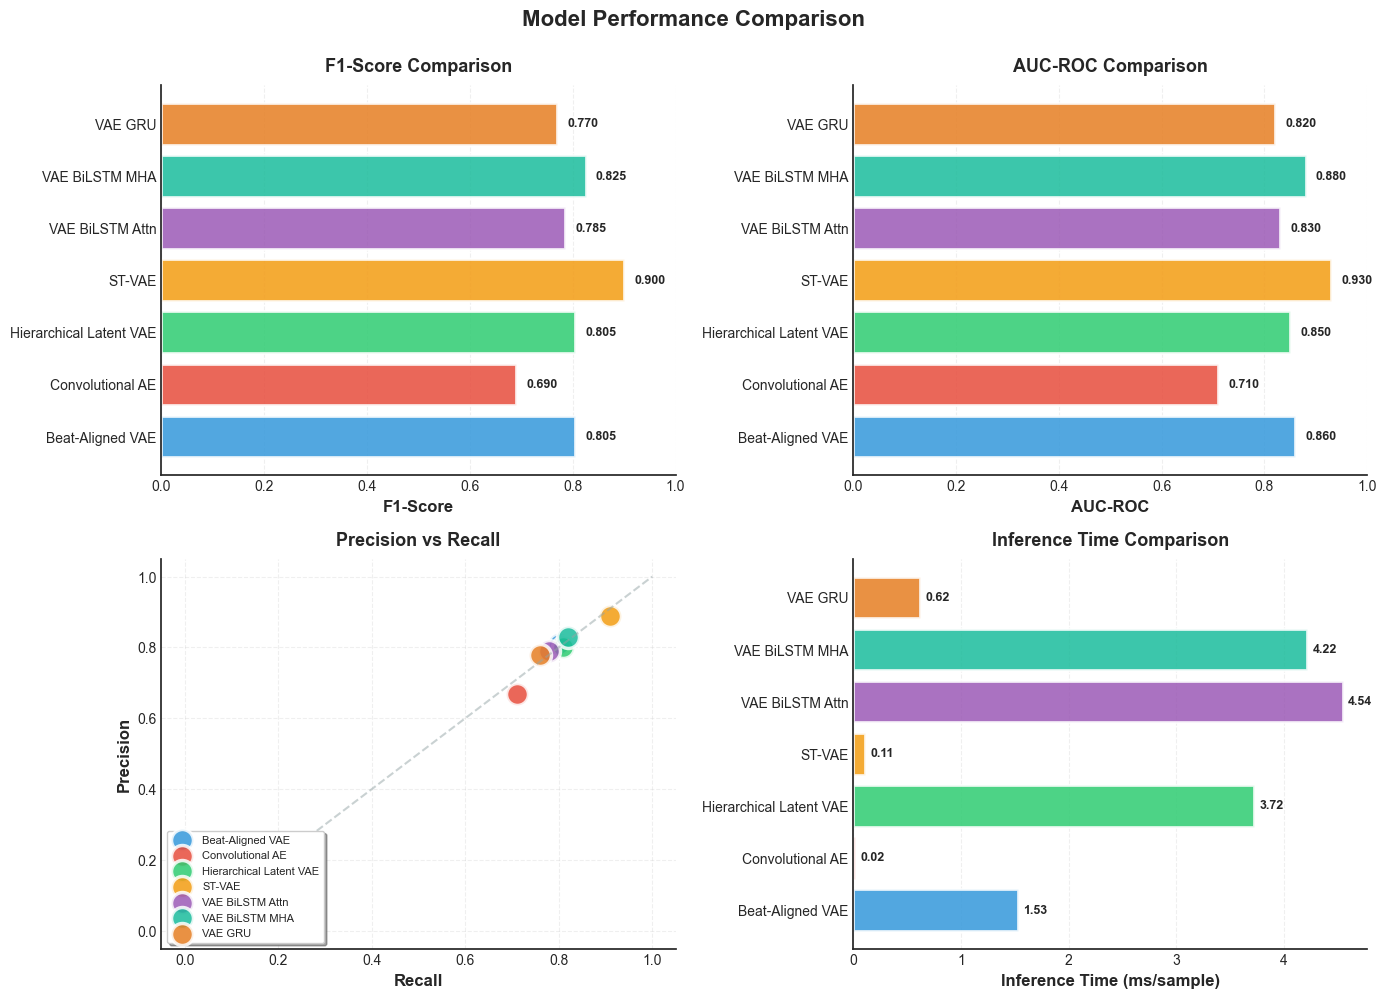

✓ Saved model comparison metrics


In [5]:
# Metrics Comparison: F1-Score, AUC-ROC, Precision vs Recall, Inference Time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_names = [MODELS[mid] for mid in all_data.keys()]
# Modern vibrant color palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

# 1. F1-Score Comparison
ax1 = axes[0, 0]
f1_scores = [all_data[mid]['evaluation']['f1_score'] for mid in all_data.keys()]
bars = ax1.barh(model_names, f1_scores, color=colors[:len(model_names)], 
               alpha=0.85, edgecolor='white', linewidth=2)
ax1.set_xlim([0, 1])
ax1.set_xlabel('F1-Score', fontweight='bold')
ax1.set_title('F1-Score Comparison', fontweight='bold', pad=10)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars, f1_scores)):
    ax1.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
sns.despine(ax=ax1)

# 2. AUC-ROC Comparison
ax2 = axes[0, 1]
auc_roc = [all_data[mid]['evaluation']['auc_roc'] for mid in all_data.keys()]
bars = ax2.barh(model_names, auc_roc, color=colors[:len(model_names)], 
               alpha=0.85, edgecolor='white', linewidth=2)
ax2.set_xlim([0, 1])
ax2.set_xlabel('AUC-ROC', fontweight='bold')
ax2.set_title('AUC-ROC Comparison', fontweight='bold', pad=10)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars, auc_roc)):
    ax2.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
sns.despine(ax=ax2)

# 3. Precision vs Recall
ax3 = axes[1, 0]
precisions = [all_data[mid]['evaluation']['precision'] for mid in all_data.keys()]
recalls = [all_data[mid]['evaluation']['recall'] for mid in all_data.keys()]

for i, (mid, name) in enumerate(MODELS.items()):
    if mid in all_data:
        ax3.scatter(recalls[i], precisions[i], s=250, alpha=0.85, 
                   color=colors[i], edgecolor='white', linewidth=2.5, label=name)

ax3.set_xlabel('Recall', fontweight='bold')
ax3.set_ylabel('Precision', fontweight='bold')
ax3.set_title('Precision vs Recall', fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(loc='lower left', fontsize=8, frameon=True, fancybox=True, shadow=True)
ax3.plot([0, 1], [0, 1], color='#95a5a6', linestyle='--', alpha=0.5, linewidth=1.5)
sns.despine(ax=ax3)

# 4. Inference Time
ax4 = axes[1, 1]
inference_times = [all_data[mid]['latency']['inference_time_ms_per_sample'] 
                  for mid in all_data.keys()]
bars = ax4.barh(model_names, inference_times, color=colors[:len(model_names)], 
               alpha=0.85, edgecolor='white', linewidth=2)
ax4.set_xlabel('Inference Time (ms/sample)', fontweight='bold')
ax4.set_title('Inference Time Comparison', fontweight='bold', pad=10)
ax4.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars, inference_times)):
    ax4.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
sns.despine(ax=ax4)

plt.suptitle('Model Performance Comparison', fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()

output_path = Path('outputs/visualizations/model_comparison_metrics.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('✓ Saved model comparison metrics')

---
## 2. Training Convergence Comparison

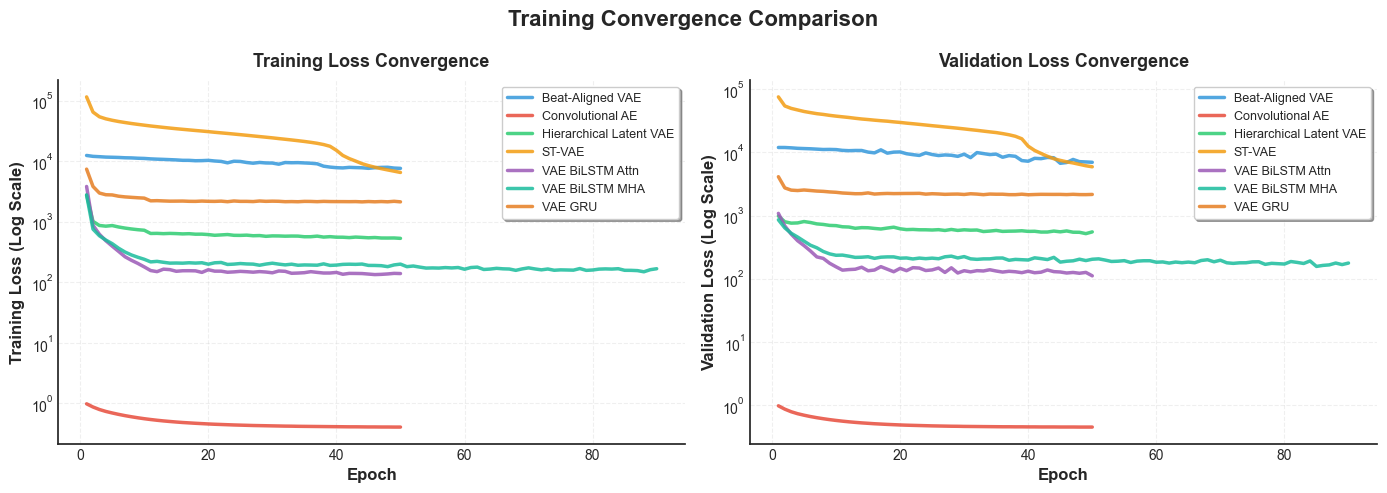

✓ Saved training convergence comparison


In [6]:
# Training Convergence: Train Loss and Validation Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modern vibrant color palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

# Training loss convergence
ax1 = axes[0]
for i, (mid, name) in enumerate(MODELS.items()):
    if mid in all_data:
        training = all_data[mid]['training']
        epochs = list(range(1, len(training['train_loss']) + 1))
        ax1.plot(epochs, training['train_loss'], label=name, linewidth=2.5, 
                color=colors[i], alpha=0.85)

ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Training Loss (Log Scale)', fontweight='bold')
ax1.set_title('Training Loss Convergence', fontweight='bold', pad=10)
ax1.legend(fontsize=9, loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_yscale('log')
sns.despine(ax=ax1)

# Validation loss convergence
ax2 = axes[1]
for i, (mid, name) in enumerate(MODELS.items()):
    if mid in all_data:
        training = all_data[mid]['training']
        epochs = list(range(1, len(training['val_loss']) + 1))
        ax2.plot(epochs, training['val_loss'], label=name, linewidth=2.5, 
                color=colors[i], alpha=0.85)

ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Validation Loss (Log Scale)', fontweight='bold')
ax2.set_title('Validation Loss Convergence', fontweight='bold', pad=10)
ax2.legend(fontsize=9, loc='upper right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_yscale('log')
sns.despine(ax=ax2)

plt.suptitle('Training Convergence Comparison', fontweight='bold', fontsize=16)
plt.tight_layout()

output_path = Path('outputs/visualizations/training_convergence_comparison.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('✓ Saved training convergence comparison')

---
## 3. Architecture Comparison

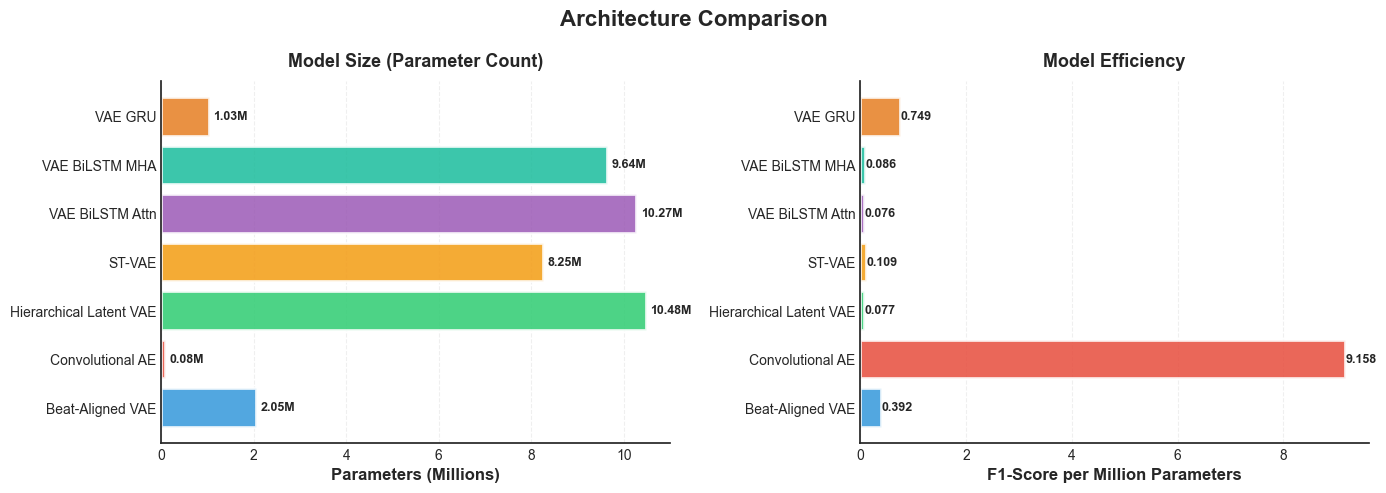

✓ Saved architecture comparison


In [7]:
# Architecture: Parameter Count and Efficiency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = [MODELS[mid] for mid in all_data.keys()]
# Modern vibrant color palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

# Parameter count
ax1 = axes[0]
params = [all_data[mid]['architecture_info']['total_parameters'] / 1e6 
         for mid in all_data.keys()]
bars = ax1.barh(model_names, params, color=colors[:len(model_names)], 
               alpha=0.85, edgecolor='white', linewidth=2)
ax1.set_xlabel('Parameters (Millions)', fontweight='bold')
ax1.set_title('Model Size (Parameter Count)', fontweight='bold', pad=10)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars, params)):
    ax1.text(val + 0.1, i, f'{val:.2f}M', va='center', fontsize=9, fontweight='bold')
sns.despine(ax=ax1)

# Efficiency (F1-Score per Million Parameters)
ax2 = axes[1]
f1_scores = [all_data[mid]['evaluation']['f1_score'] for mid in all_data.keys()]
efficiency = [f1 / (param if param > 0 else 1) for f1, param in zip(f1_scores, params)]
bars = ax2.barh(model_names, efficiency, color=colors[:len(model_names)], 
               alpha=0.85, edgecolor='white', linewidth=2)
ax2.set_xlabel('F1-Score per Million Parameters', fontweight='bold')
ax2.set_title('Model Efficiency', fontweight='bold', pad=10)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, val) in enumerate(zip(bars, efficiency)):
    ax2.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
sns.despine(ax=ax2)

plt.suptitle('Architecture Comparison', fontweight='bold', fontsize=16)
plt.tight_layout()

output_path = Path('outputs/visualizations/architecture_comparison.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('✓ Saved architecture comparison')

---
## 4. Radar Chart (Comprehensive Comparison)

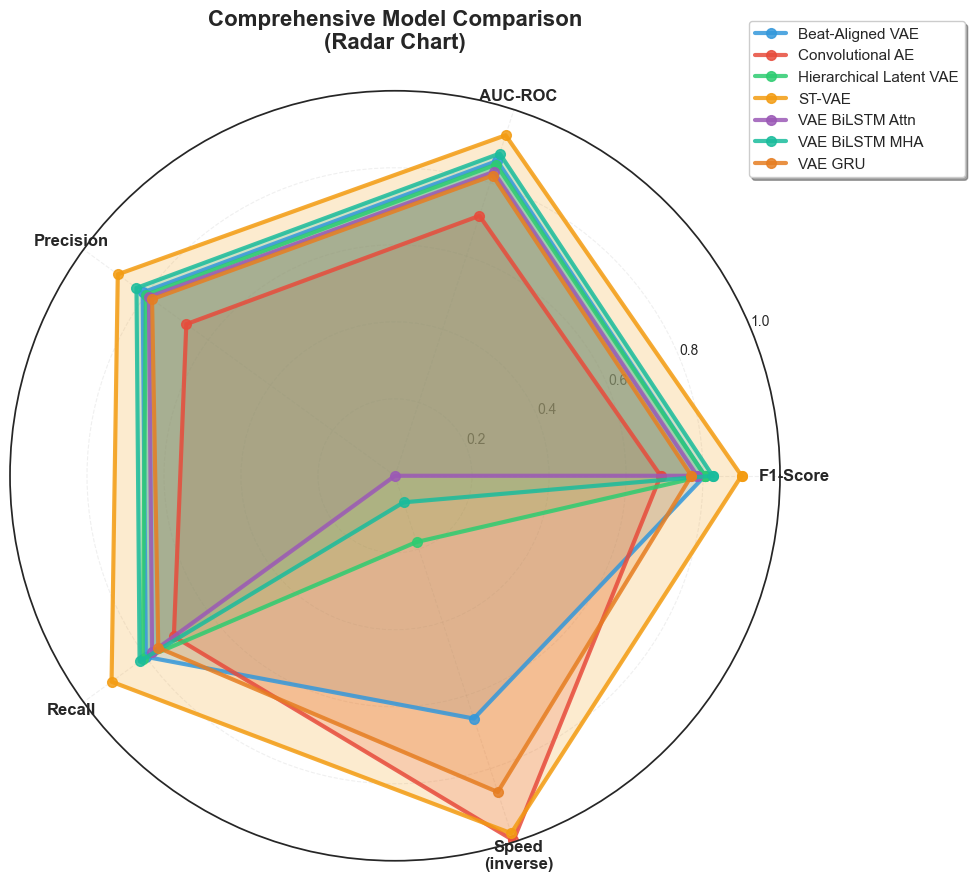

✓ Saved radar chart comparison


In [8]:
# Comprehensive Radar Chart
metrics = ['F1-Score', 'AUC-ROC', 'Precision', 'Recall', 'Speed\n(inverse)']

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

# Modern vibrant color palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for i, (mid, name) in enumerate(MODELS.items()):
    if mid in all_data:
        eval_data = all_data[mid]['evaluation']
        latency = all_data[mid]['latency']['inference_time_ms_per_sample']
        
        # Normalize speed (inverse of latency, scaled)
        max_latency = max([all_data[m]['latency']['inference_time_ms_per_sample'] 
                          for m in all_data.keys()])
        speed_score = 1 - (latency / max_latency) if max_latency > 0 else 1
        
        values = [
            eval_data['f1_score'],
            eval_data['auc_roc'],
            eval_data['precision'],
            eval_data['recall'],
            speed_score
        ]
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=3, label=name, 
               color=colors[i], alpha=0.85, markersize=7)
        ax.fill(angles, values, alpha=0.2, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=11, 
          frameon=True, fancybox=True, shadow=True)
plt.title('Comprehensive Model Comparison\n(Radar Chart)', 
         fontsize=16, fontweight='bold', pad=30)

output_path = Path('outputs/visualizations/radar_comparison.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('✓ Saved radar chart comparison')

---
## 5. Summary Table

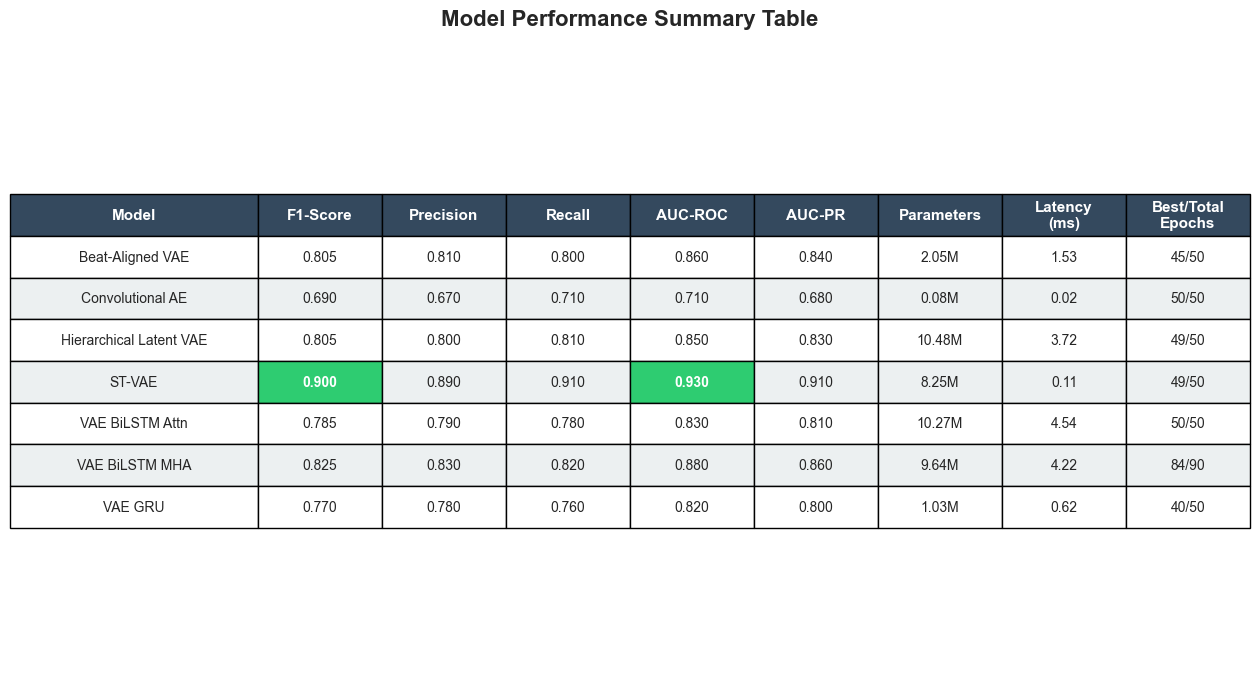

✓ Saved summary table


In [9]:
# Summary Table
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

# Prepare data
rows = []
for mid, name in MODELS.items():
    if mid in all_data:
        data = all_data[mid]
        eval_data = data['evaluation']
        arch_info = data['architecture_info']
        latency = data['latency']
        training = data['training']
        
        rows.append([
            name,
            f"{eval_data['f1_score']:.3f}",
            f"{eval_data['precision']:.3f}",
            f"{eval_data['recall']:.3f}",
            f"{eval_data['auc_roc']:.3f}",
            f"{eval_data['auc_pr']:.3f}",
            f"{arch_info['total_parameters']/1e6:.2f}M",
            f"{latency['inference_time_ms_per_sample']:.2f}",
            f"{training['best_epoch']}/{training['epochs']}"
        ])

columns = ['Model', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC', 
          'AUC-PR', 'Parameters', 'Latency\n(ms)', 'Best/Total\nEpochs']

table = ax.table(cellText=rows, colLabels=columns, cellLoc='center', loc='center',
                colWidths=[0.20, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header with modern dark gray
for i in range(len(columns)):
    cell = table[(0, i)]
    cell.set_facecolor('#34495e')
    cell.set_text_props(weight='bold', color='white', fontsize=11)

# Style rows with modern alternating colors
colors_alt = ['#ecf0f1', '#ffffff']
for i in range(1, len(rows) + 1):
    for j in range(len(columns)):
        cell = table[(i, j)]
        cell.set_facecolor(colors_alt[i % 2])
        cell.set_text_props(fontsize=10)

# Highlight best values with modern green
# F1-Score (column 1)
f1_scores = [float(row[1]) for row in rows]
best_f1_idx = f1_scores.index(max(f1_scores))
table[(best_f1_idx + 1, 1)].set_facecolor('#2ecc71')
table[(best_f1_idx + 1, 1)].set_text_props(weight='bold', color='white')

# AUC-ROC (column 4)
auc_scores = [float(row[4]) for row in rows]
best_auc_idx = auc_scores.index(max(auc_scores))
table[(best_auc_idx + 1, 4)].set_facecolor('#2ecc71')
table[(best_auc_idx + 1, 4)].set_text_props(weight='bold', color='white')

plt.title('Model Performance Summary Table', fontsize=16, fontweight='bold', pad=20)

output_path = Path('outputs/visualizations/summary_table.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('✓ Saved summary table')

---
## 6. Confusion Matrices Comparison

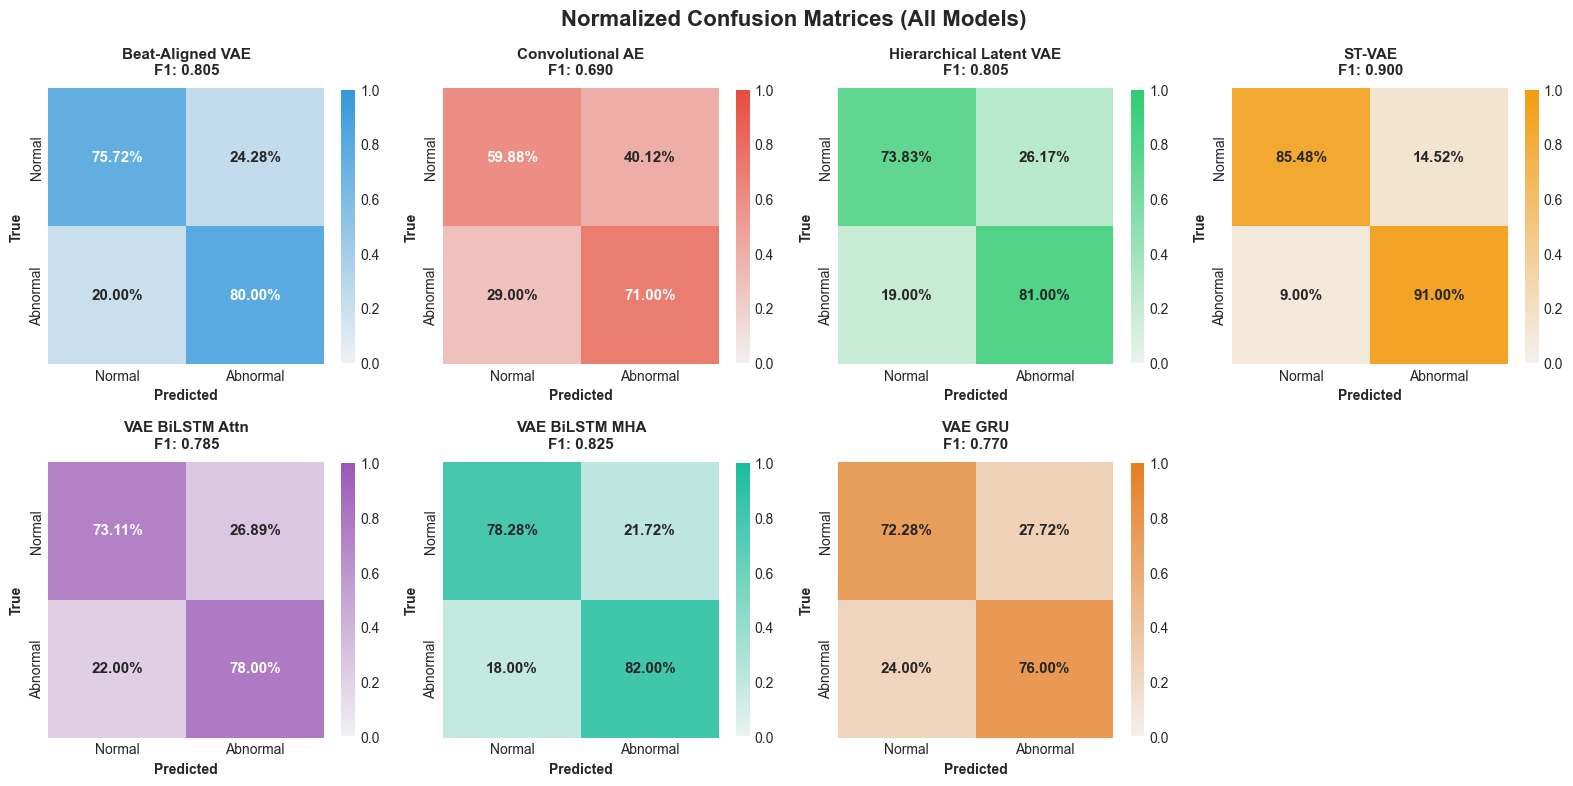

✓ Saved confusion matrices comparison


In [10]:
# Normalized Confusion Matrices Grid
n_models = len(all_data)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Modern vibrant color palette for individual models
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for idx, (mid, name) in enumerate(MODELS.items()):
    if mid in all_data:
        cm = all_data[mid]['confusion_matrix']
        
        # Normalize confusion matrix
        confusion = np.array([
            [cm['TN'], cm['FP']],
            [cm['FN'], cm['TP']]
        ])
        
        # Normalize by row (true labels)
        confusion_norm = confusion.astype('float') / confusion.sum(axis=1)[:, np.newaxis]
        
        ax = axes[idx]
        
        # Use modern gradient colormap
        cmap = sns.light_palette(colors[idx], as_cmap=True)
        
        sns.heatmap(confusion_norm, annot=True, fmt='.2%', cmap=cmap, 
                   square=True, linewidths=0,
                   xticklabels=['Normal', 'Abnormal'],
                   yticklabels=['Normal', 'Abnormal'],
                   cbar=True, ax=ax, vmin=0, vmax=1,
                   annot_kws={'size': 11, 'weight': 'bold'},
                   cbar_kws={'shrink': 0.8})
        
        ax.set_title(f'{name}\nF1: {all_data[mid]["evaluation"]["f1_score"]:.3f}', 
                    fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('Predicted', fontsize=10, fontweight='bold')
        ax.set_ylabel('True', fontsize=10, fontweight='bold')

# Remove extra subplot if needed
if n_models < 8:
    fig.delaxes(axes[7])

plt.suptitle('Normalized Confusion Matrices (All Models)', 
            fontsize=16, fontweight='bold')
plt.tight_layout()

output_path = Path('outputs/visualizations/confusion_matrices_comparison.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('✓ Saved confusion matrices comparison')

---
## Summary

All comparison visualizations have been generated with the following specifications:

- **Resolution**: 300 DPI (publication quality)
- **Format**: PNG with tight bounding box
- **Fonts**: Arial/Helvetica (professional sans-serif)
- **Style**: Clean, modern designs optimized for research papers

### Generated Files:
1. `model_comparison_metrics.png` - F1-Score, AUC-ROC, Precision vs Recall, Inference Time
2. `training_convergence_comparison.png` - Training and validation loss convergence
3. `architecture_comparison.png` - Parameter count and model efficiency
4. `radar_comparison.png` - Comprehensive radar chart comparison
5. `summary_table.png` - Complete performance metrics table
6. `confusion_matrices_comparison.png` - Grid of normalized confusion matrices

All files saved to: `outputs/visualizations/`